## Neural Dimensionality Estimation

**Created:** Friday, January 16, 2026, 14:58:05  
**Author:** @nehabinish  

This notebook estimates the dimensionality of neural ECoG data for individual subjects using Factor Analysis (FA).  

In [11]:
# %% == Autoreload ==

# Run cell to enable autoreload of modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# %% == Get working dir to set path ==

import os
import sys

try:
    from pathlib import Path # Try using pathlib 
    cwd = Path.cwd()         # Current working directory
    parent_dir = cwd.parent  # Parent directory

    # Add parent directory to system path
    sys.path.append(str(parent_dir))
    sys.path.append(str(parent_dir / 'src/'))

except Exception as e:
    # Fallback using os module if pathlib fails
    try:
        cwd = os.getcwd()
        parent_dir = os.path.dirname(cwd)

        sys.path.append(parent_dir)
        sys.path.append(os.path.join(parent_dir, 'src'))
    except Exception as ex:
        print("Could not determine workspace paths automatically.")
        print("Please ensure you are running the notebook in a proper directory.")
        print("If error persists, manually set cwd and parent_dir.")
        print("Error details:", ex)

# Notes for users:
# 1. Make sure your notebook is launched from the root project folder
#    so that the parent directory contains your modules.
# 2. If cell fails, manually set 'cwd' and 'parent_dir' at the top.
# 3. This setup is crucial for importing custom modules located in the parent directory.

In [3]:
# %% == Import modules ==

# Python standard libraries
import pickle
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Custom modules
import init as In
from dimreduction_utils import FactorAnalysis
from plot_utils import apply_plot_style, plot_neural_data, plot_cumulative_explained_variance

# Set random seeds for reproducibility
rng = np.random.default_rng(42)

In [4]:
# %% == Load synthetic example data ==

# NOTE: Data is completely synthetic and for demonstration purposes only. 
# Please refer to the Data availability section in the paper.

data_path = os.path.join(parent_dir, 'data', 'demo_data.pkl')
with open(data_path, 'rb') as f:
    data = pickle.load(f)

[INFO] Loaded plot style: /Users/nehabinish/Desktop/ContextIV_paper/AIP/pfc-m1-communication-subspace/src/custom_plotstyle.mplstyle


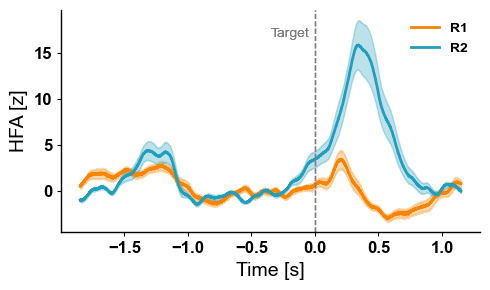

In [5]:
# %% == Plot example data ==

apply_plot_style()
fig1, ax1 = plt.subplots()
fig1 = plot_neural_data(data, fig=fig1, ax=ax1, regions=('R1', 'R2'), region_colours=In.roi_colours)
plt.show()

In [6]:
# %% == Functions to estimate data dimensionality ==

def estimate_dimensionality_cv_fa(data):
    """
    Estimates the required number of latent dimensions for the given dataset 
    using cross-validated Factor Analysis (FA).

    Args:
        data (np.ndarray): 2D array of shape [samples x features]

    Returns:
        qOpt (int): Estimated optimal number of latent dimensions
        expvar (np.ndarray): Explained variance per latent dimension
    """

    data = np.asarray(data)
    if data.ndim != 2:
        raise ValueError("Input data must be a 2D array [samples x features].")

    nsamples, nfeatures = data.shape
    if nsamples < nfeatures:
        raise ValueError(
            "Number of samples must be >= number of features "
            "(nsamples >= nfeatures)."
        )

    # Latent dimensions to test
    q = np.arange(0, nfeatures + 1)

    FA = FactorAnalysis(X=data, q=q)
    cvLoss, cvLogLike, expvar = FA.CrossValFa()

    qOpt = FA.FactorAnalysisModelSelect(cvLoss)

    return qOpt, expvar


def estimate_single_trial_dimensionality(
    data,
    regions=("R1", "R2"),
    verbose=False,
):
    """
    Estimate dimensionality for each trial and region using FA.

    Args:
        data (dict): Dictionary with trial-wise neural data.
                     Required keys:
                        - region names (e.g., 'R1', 'R2')
                     Region data shape:
                        [n_trials, n_channels, n_timepoints]
        regions (tuple): Region names to process
        verbose (bool): Enable progress display

    Returns:
        dict: {
            region_name: {
                "dims": np.ndarray [n_trials],
                "expvar": list of np.ndarray
            }
        }
    """

    n_trials = len(data[regions[0]])
    results = {}

    for region_name in regions:
        if region_name not in data:
            raise KeyError(f"Region '{region_name}' not found in data.")

        region_trials = data[region_name]

        if verbose:
            print(f"[INFO] Processing region: {region_name}")

        trial_dims = []
        trial_expvar = []

        trial_iterator = tqdm(
            range(n_trials),
            desc=f"Region {region_name}",
            disable=not verbose,
        )

        for trial_idx in trial_iterator:
            trial_data = region_trials[trial_idx].T  # [samples x features]

            dim, expvar = estimate_dimensionality_cv_fa(trial_data)

            trial_dims.append(dim)
            trial_expvar.append(expvar)

        results[region_name] = {
            "dims": np.asarray(trial_dims),
            "expvar": trial_expvar,
        }

    return results

In [7]:
# %% == Estimate dimensionality for regions R1 and R2 ==

Results = estimate_single_trial_dimensionality(data, verbose=True)

[INFO] Processing region: R1


Region R1:   0%|          | 0/50 [00:00<?, ?it/s]

[INFO] Processing region: R2


Region R2:   0%|          | 0/50 [00:00<?, ?it/s]

In [8]:
# %% == Get dimensionality results ==

dimsR1 = Results['R1']['dims']
dimsR2 = Results['R2']['dims']

print(f"Mean estimated dimensionality for R1: {np.mean(dimsR1):.2f}")
print(f"Mean estimated dimensionality for R2: {np.mean(dimsR2):.2f}")
dimensionality_dict = {'R1': dimsR1, 'R2': dimsR2}

Mean estimated dimensionality for R1: 4.46
Mean estimated dimensionality for R2: 4.22


[INFO] Loaded plot style: /Users/nehabinish/Desktop/ContextIV_paper/AIP/pfc-m1-communication-subspace/src/custom_plotstyle.mplstyle


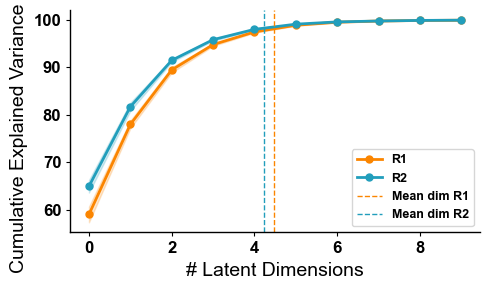

In [12]:
# == Plot cumulative explained variance ==

apply_plot_style()
fig2, ax2 = plt.subplots()
fig2 = plot_cumulative_explained_variance(Results, dimsR1, dimsR2, fig=fig2, ax=ax2, roi_colours=In.roi_colours, n_dims=10)
plt.show()